In [ ]:
import pyreadstat

_, meta457 = pyreadstat.read_dta('C:/maternal_health_project/data/IAIR7EFL.DTA', usecols=['v457'])
print(f"v457 value labels: {meta457.variable_value_labels.get('v457')}")

df457, _ = pyreadstat.read_dta('C:/maternal_health_project/data/IAIR7EFL.DTA', usecols=['v457'])
print(f"\nv457 distribution:\n{df457['v457'].value_counts(dropna=False).sort_index()}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import pickle
import warnings
import os
warnings.filterwarnings('ignore')

columns_needed = [
    'v012','v024','v025','v106','v113','v116',
    'v119','v130','v131','v149','v157','v158','v159',
    'v190','b5_01','v201','v213','v228','m14_1','m15_1',
    'm17_1','v437','v438','v445','v457','s116',
    'v136','v137'
]
# v454 removed (wrong variable — "currently pregnant"), v457 added (correct anaemia level)

print("Loading NFHS-5... please wait (1-2 mins)...")
df, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=columns_needed
)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading NFHS-5... please wait (1-2 mins)...
✅ Loaded: 724,115 rows × 28 columns


In [2]:
df_sub = df[df['m14_1'].notna()].copy()
print(f"Full dataset:  {df.shape[0]:,} women")
print(f"Subgroup:      {df_sub.shape[0]:,} women with recent births")

Full dataset:  724,115 women
Subgroup:      176,843 women with recent births


Binary Risk Label Distribution:
risk_label
0    147658
1     29185
Name: count, dtype: int64

0 = Not High Risk
1 = High Risk

High Risk rate: 16.50%


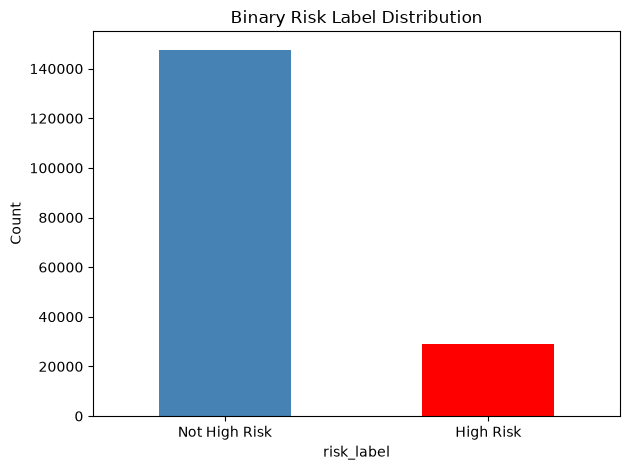

✅ Risk label plot saved.


In [3]:
def assign_risk(row):
    anc      = row['m14_1'] if pd.notna(row['m14_1']) else 0
    anaemia  = row['v457']  if pd.notna(row['v457'])  else 4   # 4 = not anemic = safe default
    alive    = row['b5_01'] if pd.notna(row['b5_01']) else 1
    loss     = row['v228']  if pd.notna(row['v228'])  else 0
    delivery = row['m15_1'] if pd.notna(row['m15_1']) else 0
    wealth   = row['v190']  if pd.notna(row['v190'])  else 3
    edu      = row['v106']  if pd.notna(row['v106'])  else 1
    age      = row['v012']  if pd.notna(row['v012'])  else 25

    high_score = 0
    if anc < 2:                        high_score += 3
    if anaemia <= 2:                   high_score += 3   # severe (1) or moderate (2)
    if alive == 0:                     high_score += 3
    if anaemia == 1:                   high_score += 2   # severe gets extra weight
    if delivery == 1 and wealth <= 1:  high_score += 2
    if age < 18 or age > 40:           high_score += 1
    if loss == 1:                      high_score += 1
    if wealth == 1 and edu == 0:       high_score += 1

    return 1 if high_score >= 4 else 0

df_sub['risk_label'] = df_sub.apply(assign_risk, axis=1)

print("Binary Risk Label Distribution:")
print(df_sub['risk_label'].value_counts())
print(f"\n0 = Not High Risk")
print(f"1 = High Risk")
print(f"\nHigh Risk rate: {df_sub['risk_label'].mean()*100:.2f}%")

os.makedirs('C:/maternal_health_project/figures/eda_plots', exist_ok=True)
df_sub['risk_label'].value_counts().plot(
    kind='bar', color=['steelblue','red'],
    title='Binary Risk Label Distribution'
)
plt.xticks([0,1],['Not High Risk','High Risk'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/eda_plots/risk_label_dist.png', dpi=150)
plt.show()
print("✅ Risk label plot saved.")

In [4]:
leakage_cols = ['m14_1','v457','b5_01','v228','m15_1','v213']
df_sub = df_sub.drop(columns=leakage_cols, errors='ignore')
df_sub = df_sub.drop(columns=['v001','m17_1','v453'], errors='ignore')

print(f"Leakage columns dropped: {leakage_cols}")
print(f"Also dropped: v001, m17_1, v453 (prior sensitivity-check removals)")
print(f"Shape after dropping: {df_sub.shape}")

remaining = [c for c in leakage_cols + ['v001','m17_1','v453'] if c in df_sub.columns]
if len(remaining) == 0:
    print("✅ No leakage/removed columns remaining")
else:
    print(f"❌ WARNING — still present: {remaining}")

Leakage columns dropped: ['m14_1', 'v457', 'b5_01', 'v228', 'm15_1', 'v213']
Also dropped: v001, m17_1, v453 (prior sensitivity-check removals)
Shape after dropping: (176843, 22)
✅ No leakage/removed columns remaining


In [5]:
# Drop v001 (primary sampling unit / cluster ID) — an arbitrary geographic identifier,
# not a meaningful clinical or SES variable. Sensitivity check (Phase 4 Cell 11) confirmed
# negligible AUC impact (+0.0045), so removing it for a cleaner, more defensible feature set.
df_sub = df_sub.drop(columns=['v001'], errors='ignore')
print(f"v001 dropped. Shape: {df_sub.shape}")

v001 dropped. Shape: (176843, 22)


In [6]:
# Drop v001 (arbitrary cluster ID), m17_1 (c-section — plausibly post-outcome timing),
# and v453 (hemoglobin — near-complete proxy for the excluded anaemia grade v454).
# Sensitivity checks (Phase 4 Cells 11-13) confirmed all three contribute negligibly
# to AUC (<0.005 each), so removing them for a cleaner, more defensible feature set.
df_sub = df_sub.drop(columns=['v001', 'm17_1', 'v453'], errors='ignore')
print(f"v001, m17_1, v453 dropped. Shape: {df_sub.shape}")

v001, m17_1, v453 dropped. Shape: (176843, 22)


In [7]:
from sklearn.model_selection import train_test_split

feature_cols_raw = [c for c in df_sub.columns if c != 'risk_label']
X_raw = df_sub[feature_cols_raw]
y = df_sub['risk_label']

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
X_train_raw, X_cal_raw, y_train, y_cal = train_test_split(
    X_trainval_raw, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print(f"Train:       {X_train_raw.shape[0]:,} rows ({y_train.mean()*100:.2f}% High Risk)")
print(f"Calibration: {X_cal_raw.shape[0]:,} rows ({y_cal.mean()*100:.2f}% High Risk)")
print(f"Test:        {X_test_raw.shape[0]:,} rows ({y_test.mean()*100:.2f}% High Risk)")

Train:       113,179 rows (16.50% High Risk)
Calibration: 28,295 rows (16.50% High Risk)
Test:        35,369 rows (16.50% High Risk)


In [8]:
from sklearn.impute import SimpleImputer

continuous_cols = ['v012','v201','v437','v438','v445','v136','v137']
categorical_cols = ['v106','v113','v116','v119','v130','v131',
                    'v149','v157','v158','v159','v190',
                    'v024','v025','s116']

continuous_cols  = [c for c in continuous_cols  if c in X_train_raw.columns]
categorical_cols = [c for c in categorical_cols if c in X_train_raw.columns]

X_train_imp = X_train_raw.copy()
X_cal_imp   = X_cal_raw.copy()
X_test_imp  = X_test_raw.copy()

imp_med = SimpleImputer(strategy='median')
X_train_imp[continuous_cols] = imp_med.fit_transform(X_train_raw[continuous_cols])
X_cal_imp[continuous_cols]   = imp_med.transform(X_cal_raw[continuous_cols])
X_test_imp[continuous_cols]  = imp_med.transform(X_test_raw[continuous_cols])

imp_mod = SimpleImputer(strategy='most_frequent')
X_train_imp[categorical_cols] = imp_mod.fit_transform(X_train_raw[categorical_cols])
X_cal_imp[categorical_cols]   = imp_mod.transform(X_cal_raw[categorical_cols])
X_test_imp[categorical_cols]  = imp_mod.transform(X_test_raw[categorical_cols])

print("✅ Imputation done — fitted on TRAIN only.")
print(f"Missing remaining — train: {X_train_imp.isnull().sum().sum()}, "
      f"cal: {X_cal_imp.isnull().sum().sum()}, test: {X_test_imp.isnull().sum().sum()}")

✅ Imputation done — fitted on TRAIN only.
Missing remaining — train: 0, cal: 0, test: 0


In [9]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
X_train_enc = X_train_imp.copy()
X_cal_enc   = X_cal_imp.copy()
X_test_enc  = X_test_imp.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_imp[col].astype(str))
    known = set(le.classes_)

    def safe_transform(series, le=le, known=known):
        vals = series.astype(str).apply(lambda v: v if v in known else le.classes_[0])
        return le.transform(vals)

    X_cal_enc[col]  = safe_transform(X_cal_imp[col])
    X_test_enc[col] = safe_transform(X_test_imp[col])
    encoders[col] = le

print("✅ Encoding done — fitted on TRAIN only.")
print(f"Train shape: {X_train_enc.shape} | Cal shape: {X_cal_enc.shape} | Test shape: {X_test_enc.shape}")

✅ Encoding done — fitted on TRAIN only.
Train shape: (113179, 21) | Cal shape: (28295, 21) | Test shape: (35369, 21)


In [10]:
from imblearn.combine import SMOTETomek

print("Before SMOTETomek (train):")
print(pd.Series(y_train).value_counts())

smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_enc, y_train)

print(f"\nAfter SMOTETomek (train):")
print(pd.Series(y_train_bal).value_counts())
print("\n✅ SMOTETomek applied to training only.")

Before SMOTETomek (train):
risk_label
0    94501
1    18678
Name: count, dtype: int64

After SMOTETomek (train):
risk_label
0    93542
1    93542
Name: count, dtype: int64

✅ SMOTETomek applied to training only.


In [11]:
os.makedirs('C:/maternal_health_project/models', exist_ok=True)

feature_cols = list(X_train_bal.columns)

data_bundle = {
    'X_train_bal': X_train_bal, 'y_train_bal': y_train_bal,
    'X_train_pre_smote': X_train_enc, 'y_train_pre_smote': y_train,
    'X_cal': X_cal_enc, 'y_cal': y_cal,
    'X_test': X_test_enc, 'y_test': y_test,
    'feature_cols': feature_cols,
    'imputer_median': imp_med, 'imputer_mode': imp_mod,
    'encoders': encoders
}

with open('C:/maternal_health_project/models/train_test_data.pkl','wb') as f:
    pickle.dump(data_bundle, f)

size = os.path.getsize('C:/maternal_health_project/models/train_test_data.pkl')
print(f"✅ Saved. File size: {size:,} bytes")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

✅ Saved. File size: 68,305,111 bytes
Feature columns (21): ['v012', 'v024', 'v025', 'v106', 'v113', 'v116', 'v119', 'v130', 'v131', 'v136', 'v137', 'v149', 'v157', 'v158', 'v159', 'v190', 'v201', 'v437', 'v438', 'v445', 's116']


In [12]:
with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d = pickle.load(f)

print("="*50)
print("PHASE 2 COMPLETE — v457 ANAEMIA FIX APPLIED")
print("="*50)
print(f"X_train_bal shape: {d['X_train_bal'].shape}")
print(f"X_cal shape:        {d['X_cal'].shape}")
print(f"X_test shape:        {d['X_test'].shape}")
print(f"Features:            {len(d['feature_cols'])}")

leakage = [c for c in leakage_cols + ['v001','m17_1','v453'] if c in d['feature_cols']]
print(f"\nLeakage/removed-variable check: {leakage}")

if len(leakage) == 0 and d['y_test'].nunique() == 2:
    print("\n✅ Binary labels confirmed.")
    print("✅ No leakage columns present.")
    print("✅ Phase 2 complete. Ready for Phase 3.")
else:
    print("\n❌ Something wrong — recheck.")

PHASE 2 COMPLETE — v457 ANAEMIA FIX APPLIED
X_train_bal shape: (187084, 21)
X_cal shape:        (28295, 21)
X_test shape:        (35369, 21)
Features:            21

Leakage/removed-variable check: []

✅ Binary labels confirmed.
✅ No leakage columns present.
✅ Phase 2 complete. Ready for Phase 3.


In [13]:
import pyreadstat
import pickle

with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d = pickle.load(f)
feature_cols = d['feature_cols']  # should no longer include v001

_, meta = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=feature_cols,
    metadataonly=True
)

print("Confirmed variable labels from NFHS-5 codebook:")
print("-"*55)
for var in feature_cols:
    label = meta.column_names_to_labels.get(var, 'NOT FOUND')
    print(f"{var}: {label}")

Confirmed variable labels from NFHS-5 codebook:
-------------------------------------------------------
v012: respondent's current age
v024: state
v025: type of place of residence
v106: highest educational level
v113: source of drinking water
v116: type of toilet facility
v119: household has: electricity
v130: religion
v131: ethnicity
v136: number of household members (listed)
v137: number of children 5 and under in household (de jure)
v149: educational attainment
v157: frequency of reading newspaper or magazine
v158: frequency of listening to radio
v159: frequency of watching television
v190: wealth index combined
v201: total children ever born
v437: respondent's weight in kilograms (1 decimal)
v438: respondent's height in centimeters (1 decimal)
v445: body mass index
s116: belong to a scheduled caste, a scheduled tribe, other backward class


In [14]:
import pyreadstat

_, meta5 = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=['v454'],
    metadataonly=True
)
print(f"NFHS-5 v454 label: {meta5.column_names_to_labels.get('v454', 'NOT FOUND')}")

# Also check value labels (the category meanings), not just the variable label
_, meta5_full = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=['v454']
)
print(f"\nNFHS-5 v454 value labels: {meta5_full.variable_value_labels.get('v454', 'none found')}")

NFHS-5 v454 label: currently pregnant (from household questionnaire)

NFHS-5 v454 value labels: {0: "no/don't know", 1: 'yes'}


In [15]:
import pyreadstat

_, meta5_full = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=['v454']
)
print(f"v454 variable label: {meta5_full.column_names_to_labels.get('v454')}")
print(f"v454 value labels: {meta5_full.variable_value_labels.get('v454')}")

df454, _ = pyreadstat.read_dta('C:/maternal_health_project/data/IAIR7EFL.DTA', usecols=['v454'])
print(f"\nv454 value distribution:\n{df454['v454'].value_counts(dropna=False)}")

# Also check what DHS actually calls the anaemia variable — commonly v456 or v457, not v454
_, meta_anaemia_check = pyreadstat.read_dta(
    'C:/maternal_health_project/data/IAIR7EFL.DTA',
    usecols=['v456','v457'],
    metadataonly=True
)
for var in ['v456','v457']:
    label = meta_anaemia_check.column_names_to_labels.get(var, 'NOT FOUND')
    print(f"\n{var}: {label}")

v454 variable label: currently pregnant (from household questionnaire)
v454 value labels: {0: "no/don't know", 1: 'yes'}

v454 value distribution:
v454
0    695707
1     28408
Name: count, dtype: int64

v456: hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)

v457: anemia level
